# 📘 U4 — Generación de Código Destino
## Procesadores del Lenguaje II — Ejercicios Resueltos (Nivel Introductorio)

**Bibliografía base:**  
Aho, A. V., Sethi, R., & Lam, M. S. (2011). *Compiladores.* Pearson Educación de México.

---

Este cuaderno contiene **40 ejercicios resueltos** que cubren las seis secciones de la Unidad 4:

| Sección | Tema | Ejercicios |
|---------|------|------------|
| 1 | Introducción a la Generación de Código Destino | 1 – 5 |
| 2 | Aspectos en la generación de código | 6 – 12 |
| 3 | Bloques básicos y grafos de flujo | 13 – 22 |
| 4 | Generación de código sencillo | 23 – 30 |
| 5 | Uso eficiente de registros | 31 – 36 |
| 6 | Optimización a nivel de código máquina | 37 – 40 |

> **Nota:** Para ejecutar el cuaderno en Google Colab, ve a  
> `Entorno de ejecución → Ejecutar todo`.

---
## 📌 Sección 1 — Introducción a la Generación de Código Destino

La **generación de código** es la fase final del compilador. Transforma la Representación Intermedia (RI) —independiente de la arquitectura— en instrucciones concretas de la máquina destino.

### 🔹 Ejercicio 1 — Fases de un compilador
**Enunciado:** Enumera las fases de un compilador e indica cuál produce la Representación Intermedia (RI) y cuál la transforma en código máquina.

In [42]:
fases = [
    ("1. Análisis léxico",        "Produce tokens"),
    ("2. Análisis sintáctico",     "Produce árbol de análisis (AST)"),
    ("3. Análisis semántico",      "Verifica tipos y produce AST decorado"),
    ("4. Generación de RI",        "★ Produce Representación Intermedia (RI)"),
    ("5. Optimización de RI",      "Mejora la RI (opcional)"),
    ("6. Generación de código",    "★ Transforma la RI en código máquina"),
]

print("Fases del compilador:\n")
for fase, descripcion in fases:
    print(f"  {fase:35s} → {descripcion}")

Fases del compilador:

  1. Análisis léxico                  → Produce tokens
  2. Análisis sintáctico              → Produce árbol de análisis (AST)
  3. Análisis semántico               → Verifica tipos y produce AST decorado
  4. Generación de RI                 → ★ Produce Representación Intermedia (RI)
  5. Optimización de RI               → Mejora la RI (opcional)
  6. Generación de código             → ★ Transforma la RI en código máquina


### 🔹 Ejercicio 2 — ¿Qué hace el generador de código?
**Enunciado:** Describe con tus propias palabras la tarea principal del generador de código y los tres problemas fundamentales que debe resolver.

In [43]:
tarea_principal = """
El generador de código toma la RI (abstracta, independiente de la máquina)
y produce un programa equivalente en el lenguaje de la máquina destino.
"""

problemas_fundamentales = {
    "1. Selección de instrucciones":
        "Elegir qué instrucción(es) de la máquina implementan cada operación de la RI.",
    "2. Asignación de registros":
        "Decidir qué variables/temporales se mantienen en registros de la CPU.",
    "3. Orden de evaluación":
        "Determinar el orden en que se ejecutan las instrucciones para aprovechar la CPU.",
}

print("Tarea principal:", tarea_principal)
print("Problemas fundamentales:")
for k, v in problemas_fundamentales.items():
    print(f"  {k}: {v}")

Tarea principal: 
El generador de código toma la RI (abstracta, independiente de la máquina)
y produce un programa equivalente en el lenguaje de la máquina destino.

Problemas fundamentales:
  1. Selección de instrucciones: Elegir qué instrucción(es) de la máquina implementan cada operación de la RI.
  2. Asignación de registros: Decidir qué variables/temporales se mantienen en registros de la CPU.
  3. Orden de evaluación: Determinar el orden en que se ejecutan las instrucciones para aprovechar la CPU.


### 🔹 Ejercicio 3 — Representación intermedia como entrada
**Enunciado:** Dado el código fuente `a = b + c * d`, muestra la RI en forma de cuádruplos y explica por qué la RI es ventajosa respecto al código fuente directo.

In [44]:
# Cuádruplos: (operador, operando1, operando2, resultado)
cuadruplos = [
    ("*", "c", "d", "t1"),   # t1 = c * d
    ("+", "b", "t1", "t2"),  # t2 = b + t1
    (":=", "t2", "", "a"),   # a  = t2
]

print("RI en cuádruplos para: a = b + c * d")
print(f"{'#':<4} {'Op':<6} {'Arg1':<8} {'Arg2':<8} {'Res':<6}")
print("-" * 35)
for i, (op, a1, a2, res) in enumerate(cuadruplos, 1):
    print(f"{i:<4} {op:<6} {a1:<8} {a2:<8} {res:<6}")

print("\nVentajas de la RI:")
ventajas = [
    "Es independiente de la máquina destino.",
    "Facilita la optimización antes de generar código final.",
    "Separa el análisis del front-end de la síntesis del back-end.",
    "Permite reutilizar el front-end para múltiples máquinas destino.",
]
for v in ventajas:
    print(f"  • {v}")

RI en cuádruplos para: a = b + c * d
#    Op     Arg1     Arg2     Res   
-----------------------------------
1    *      c        d        t1    
2    +      b        t1       t2    
3    :=     t2                a     

Ventajas de la RI:
  • Es independiente de la máquina destino.
  • Facilita la optimización antes de generar código final.
  • Separa el análisis del front-end de la síntesis del back-end.
  • Permite reutilizar el front-end para múltiples máquinas destino.


### 🔹 Ejercicio 4 — Tabla de símbolos como apoyo
**Enunciado:** Simula una tabla de símbolos sencilla con las variables `x`, `y`, `z` y muestra cómo el generador de código la consulta para conocer el tipo y la posición en memoria de cada variable.

In [45]:
# Tabla de símbolos: nombre → {tipo, alcance, offset}
tabla_simbolos = {
    "x": {"tipo": "int",   "alcance": "global", "offset": 0},
    "y": {"tipo": "float", "alcance": "global", "offset": 4},
    "z": {"tipo": "int",   "alcance": "local",  "offset": 8},
}

def consultar_variable(nombre):
    if nombre in tabla_simbolos:
        info = tabla_simbolos[nombre]
        print(f"Variable '{nombre}': tipo={info['tipo']}, "
              f"alcance={info['alcance']}, offset={info['offset']} bytes")
    else:
        print(f"Variable '{nombre}' no encontrada.")

print("Consultas del generador de código a la tabla de símbolos:")
for var in ["x", "y", "z", "w"]:
    consultar_variable(var)

Consultas del generador de código a la tabla de símbolos:
Variable 'x': tipo=int, alcance=global, offset=0 bytes
Variable 'y': tipo=float, alcance=global, offset=4 bytes
Variable 'z': tipo=int, alcance=local, offset=8 bytes
Variable 'w' no encontrada.


### 🔹 Ejercicio 5 — Ejemplo mínimo: RI → código ensamblador
**Enunciado:** Traduce la instrucción RI `t1 := a + b` a instrucciones ensamblador hipotético de tres registros (`R0`, `R1`, `R2`). Asume que `a` y `b` están en memoria.

In [46]:
# Instrucción RI
instruccion_RI = "t1 := a + b"

# Traducción a ensamblador hipotético
codigo_ensamblador = [
    "LD  R0, a    ; Cargar 'a' desde memoria al registro R0",
    "LD  R1, b    ; Cargar 'b' desde memoria al registro R1",
    "ADD R2, R0, R1  ; R2 = R0 + R1  (resultado t1)",
]

print(f"Instrucción RI:  {instruccion_RI}")
print("\nCódigo ensamblador generado:")
for i, ins in enumerate(codigo_ensamblador, 1):
    print(f"  {i}. {ins}")

print("\n→ El resultado de t1 queda almacenado en el registro R2.")

Instrucción RI:  t1 := a + b

Código ensamblador generado:
  1. LD  R0, a    ; Cargar 'a' desde memoria al registro R0
  2. LD  R1, b    ; Cargar 'b' desde memoria al registro R1
  3. ADD R2, R0, R1  ; R2 = R0 + R1  (resultado t1)

→ El resultado de t1 queda almacenado en el registro R2.


---
## 📌 Sección 2 — Aspectos en la Generación de Código

Tres aspectos clave: **entrada** (la RI + tabla de símbolos), **máquina destino** (repertorio de instrucciones, registros, modos de direccionamiento) y **gestión de memoria** (código, datos estáticos, pila, montículo).

### 🔹 Ejercicio 6 — Repertorio de instrucciones
**Enunciado:** Modela un repertorio de instrucciones hipotético (ISA) y calcula el costo de cada instrucción basándote en el número de accesos a memoria.

In [47]:
# Modelo simple de ISA con costos (nº accesos a memoria = ciclos adicionales)
isa = {
    "LD  Ri, M"    : {"descripcion": "Carga desde memoria al registro",   "costo": 2},
    "ST  M, Ri"    : {"descripcion": "Almacena registro en memoria",       "costo": 2},
    "ADD Ri,Rj,Rk" : {"descripcion": "Suma dos registros",                 "costo": 1},
    "SUB Ri,Rj,Rk" : {"descripcion": "Resta dos registros",                "costo": 1},
    "MUL Ri,Rj,Rk" : {"descripcion": "Multiplica dos registros",           "costo": 1},
    "MOV Ri, Rj"   : {"descripcion": "Copia entre registros",              "costo": 1},
    "JMP etiqueta" : {"descripcion": "Salto incondicional",                "costo": 1},
    "BEQ Ri,Rj,et" : {"descripcion": "Salto si Ri == Rj",                  "costo": 1},
}

print(f"{'Instrucción':<20} {'Descripción':<40} {'Costo'}")
print("-" * 68)
for instr, info in isa.items():
    print(f"{instr:<20} {info['descripcion']:<40} {info['costo']}")

Instrucción          Descripción                              Costo
--------------------------------------------------------------------
LD  Ri, M            Carga desde memoria al registro          2
ST  M, Ri            Almacena registro en memoria             2
ADD Ri,Rj,Rk         Suma dos registros                       1
SUB Ri,Rj,Rk         Resta dos registros                      1
MUL Ri,Rj,Rk         Multiplica dos registros                 1
MOV Ri, Rj           Copia entre registros                    1
JMP etiqueta         Salto incondicional                      1
BEQ Ri,Rj,et         Salto si Ri == Rj                        1


### 🔹 Ejercicio 7 — Modos de direccionamiento
**Enunciado:** Implementa una función que, dado el modo de direccionamiento, genere la instrucción de carga (`LD`) correspondiente.

In [48]:
def generar_carga(registro_destino, modo, valor_o_base=None, offset=None):
    """
    Genera la instrucción LD según el modo de direccionamiento.
    Modos soportados:
      'inmediato'  → LD Ri, #valor
      'directo'    → LD Ri, dirección
      'indirecto'  → LD Ri, (Rj)
      'indexado'   → LD Ri, offset(Rj)
    """
    if modo == "inmediato":
        return f"LD  {registro_destino}, #{valor_o_base}     ; inmediato"
    elif modo == "directo":
        return f"LD  {registro_destino}, {valor_o_base}      ; directo (var/dirección)"
    elif modo == "indirecto":
        return f"LD  {registro_destino}, ({valor_o_base})    ; indirecto (puntero)"
    elif modo == "indexado":
        return f"LD  {registro_destino}, {offset}({valor_o_base})  ; indexado (arreglo)"
    else:
        return "Modo desconocido"

# Ejemplos de uso
print("Ejemplos de instrucciones de carga:")
print(generar_carga("R0", "inmediato",  42))
print(generar_carga("R1", "directo",    "x"))
print(generar_carga("R2", "indirecto",  "R3"))
print(generar_carga("R4", "indexado",   "R5", 8))

Ejemplos de instrucciones de carga:
LD  R0, #42     ; inmediato
LD  R1, x      ; directo (var/dirección)
LD  R2, (R3)    ; indirecto (puntero)
LD  R4, 8(R5)  ; indexado (arreglo)


### 🔹 Ejercicio 8 — Áreas de memoria
**Enunciado:** Simula la distribución de memoria de un programa compilado con las áreas: código, datos estáticos, pila y montículo.

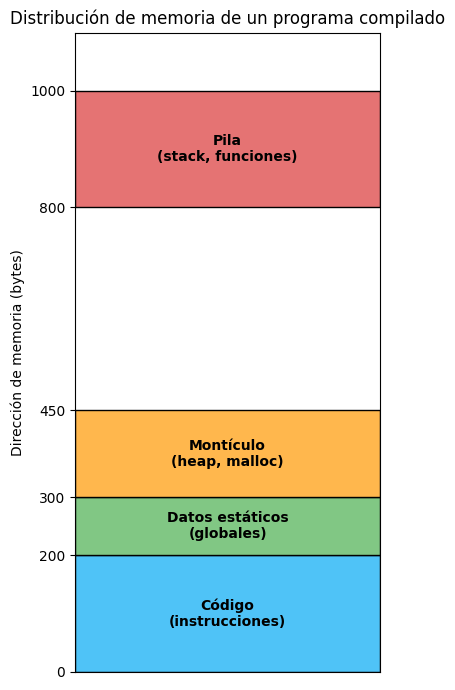


Resumen de áreas:
  Código (instrucciones)         inicio=    0  tamaño=200
  Datos estáticos (globales)     inicio=  200  tamaño=100
  Montículo (heap, malloc)       inicio=  300  tamaño=150
  Pila (stack, funciones)        inicio=  800  tamaño=200


In [49]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Definición de áreas (nombre, dirección inicial, tamaño en bytes)
areas = [
    {"nombre": "Código\n(instrucciones)",   "inicio": 0,    "tam": 200, "color": "#4fc3f7"},
    {"nombre": "Datos estáticos\n(globales)","inicio": 200,  "tam": 100, "color": "#81c784"},
    {"nombre": "Montículo\n(heap, malloc)",  "inicio": 300,  "tam": 150, "color": "#ffb74d"},
    {"nombre": "Pila\n(stack, funciones)",   "inicio": 800,  "tam": 200, "color": "#e57373"},
]

fig, ax = plt.subplots(figsize=(4, 7))
for a in areas:
    ax.barh(a["inicio"] + a["tam"]/2, 1, height=a["tam"],
            color=a["color"], edgecolor="black", align="center")
    ax.text(0.5, a["inicio"] + a["tam"]/2, a["nombre"],
            ha="center", va="center", fontsize=10, fontweight="bold")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1100)
ax.set_yticks([0, 200, 300, 450, 800, 1000])
ax.set_yticklabels(["0", "200", "300", "450", "800", "1000"])
ax.set_xticks([])
ax.set_ylabel("Dirección de memoria (bytes)")
ax.set_title("Distribución de memoria de un programa compilado")
plt.tight_layout()
plt.show()

print("\nResumen de áreas:")
for a in areas:
    print(f"  {a['nombre'].replace(chr(10),' '):<30} inicio={a['inicio']:>5}  tamaño={a['tam']}")

### 🔹 Ejercicio 9 — Pila de activación
**Enunciado:** Simula la pila de activación cuando `main()` llama a `f(x)` y `f(x)` llama a `g(y)`. Muestra los registros de activación.

In [50]:
class PilaActivacion:
    def __init__(self):
        self.pila = []

    def llamar(self, funcion, parametros, vars_locales):
        registro = {
            "función": funcion,
            "parámetros": parametros,
            "variables_locales": vars_locales,
            "dirección_retorno": f"instrucción_después_de_call_{funcion}",
        }
        self.pila.append(registro)
        print(f"  → CALL {funcion}: se crea registro de activación")

    def retornar(self):
        if self.pila:
            registro = self.pila.pop()
            print(f"  ← RETURN de {registro['función']}: se destruye registro de activación")

    def mostrar(self):
        print("\n  Estado actual de la pila (tope = arriba):")
        for reg in reversed(self.pila):
            print(f"    [ {reg['función']}  params={reg['parámetros']}  "
                  f"locals={reg['variables_locales']} ]")
        print("    ╚══════════ fondo de la pila ══════════╝")

pila = PilaActivacion()
print("Secuencia de llamadas:")
pila.llamar("main", [], ["resultado"])
pila.llamar("f", ["x=5"], ["temp1"])
pila.llamar("g", ["y=3"], ["local_a"])
pila.mostrar()

print("\nSecuencia de retornos:")
pila.retornar()  # g retorna
pila.retornar()  # f retorna
pila.retornar()  # main retorna
pila.mostrar()

Secuencia de llamadas:
  → CALL main: se crea registro de activación
  → CALL f: se crea registro de activación
  → CALL g: se crea registro de activación

  Estado actual de la pila (tope = arriba):
    [ g  params=['y=3']  locals=['local_a'] ]
    [ f  params=['x=5']  locals=['temp1'] ]
    [ main  params=[]  locals=['resultado'] ]
    ╚══════════ fondo de la pila ══════════╝

Secuencia de retornos:
  ← RETURN de g: se destruye registro de activación
  ← RETURN de f: se destruye registro de activación
  ← RETURN de main: se destruye registro de activación

  Estado actual de la pila (tope = arriba):
    ╚══════════ fondo de la pila ══════════╝


### 🔹 Ejercicio 10 — Costo de una secuencia de instrucciones
**Enunciado:** Dada una secuencia de instrucciones, calcula el costo total usando la ISA definida en el Ejercicio 6.

In [51]:
# Usamos el diccionario de costos del Ejercicio 6
costos_instruccion = {
    "LD": 2, "ST": 2, "ADD": 1, "SUB": 1,
    "MUL": 1, "MOV": 1, "JMP": 1, "BEQ": 1,
}

def costo_secuencia(instrucciones):
    """Calcula el costo total de una lista de instrucciones."""
    total = 0
    print(f"{'Instrucción':<30} {'Costo'}")
    print("-" * 40)
    for instr in instrucciones:
        opcode = instr.split()[0]
        c = costos_instruccion.get(opcode, 1)
        total += c
        print(f"  {instr:<28} {c}")
    print("-" * 40)
    print(f"  {'Costo total':<28} {total}")
    return total

# Secuencia para: a = b + c
secuencia = [
    "LD  R0, b",
    "LD  R1, c",
    "ADD R2, R0, R1",
    "ST  a, R2",
]
print("Secuencia para: a = b + c")
costo_secuencia(secuencia)

Secuencia para: a = b + c
Instrucción                    Costo
----------------------------------------
  LD  R0, b                    2
  LD  R1, c                    2
  ADD R2, R0, R1               1
  ST  a, R2                    2
----------------------------------------
  Costo total                  7


7

### 🔹 Ejercicio 11 — Comparación de dos traducciones
**Enunciado:** Compara el costo de dos traducciones diferentes para `x = x + 1` y determina cuál es más eficiente.

In [52]:
costos = {"LD": 2, "ST": 2, "ADD": 1, "INC": 1, "MOV": 1}

def calcular_costo(secuencia):
    return sum(costos.get(i.split()[0], 1) for i in secuencia)

# Opción A: x en memoria, sin registros optimizados
opcionA = [
    "LD  R0, x",       # carga x
    "ADD R0, R0, #1",  # incrementa
    "ST  x, R0",       # guarda en memoria
]

# Opción B: x ya está en R0 (de una operación anterior)
opcionB = [
    "ADD R0, R0, #1",  # solo incrementa (x ya está en R0)
]

costoA = calcular_costo(opcionA)
costoB = calcular_costo(opcionB)

print(f"Opción A (x en memoria): costo = {costoA}")
for ins in opcionA: print(f"  {ins}")

print(f"\nOpción B (x ya en registro): costo = {costoB}")
for ins in opcionB: print(f"  {ins}")

ganador = "A" if costoA < costoB else "B"
print(f"\n→ La Opción {ganador} es más eficiente "
      f"(ahorra {abs(costoA - costoB)} unidades de costo).")
print("  Conclusión: mantener variables en registros reduce los accesos a memoria.")

Opción A (x en memoria): costo = 5
  LD  R0, x
  ADD R0, R0, #1
  ST  x, R0

Opción B (x ya en registro): costo = 1
  ADD R0, R0, #1

→ La Opción B es más eficiente (ahorra 4 unidades de costo).
  Conclusión: mantener variables en registros reduce los accesos a memoria.


### 🔹 Ejercicio 12 — Clasificación de variables por área de memoria
**Enunciado:** Dada una lista de declaraciones de variables, clasifícalas en el área de memoria que ocuparán.

In [53]:
variables = [
    {"nombre": "PI",      "tipo": "const float",  "alcance": "global"},
    {"nombre": "contador","tipo": "int",           "alcance": "global"},
    {"nombre": "i",       "tipo": "int",           "alcance": "local_función"},
    {"nombre": "buffer",  "tipo": "int*",          "alcance": "heap (malloc)"},
    {"nombre": "temp",    "tipo": "int",           "alcance": "local_función"},
]

def clasificar(var):
    if "const" in var["tipo"] or var["alcance"] == "global":
        return "Datos estáticos"
    elif var["alcance"] == "heap (malloc)":
        return "Montículo (heap)"
    else:
        return "Pila (stack)"

print(f"{'Variable':<12} {'Tipo':<14} {'Alcance':<20} {'Área de memoria'}")
print("-" * 70)
for v in variables:
    area = clasificar(v)
    print(f"{v['nombre']:<12} {v['tipo']:<14} {v['alcance']:<20} {area}")

Variable     Tipo           Alcance              Área de memoria
----------------------------------------------------------------------
PI           const float    global               Datos estáticos
contador     int            global               Datos estáticos
i            int            local_función        Pila (stack)
buffer       int*           heap (malloc)        Montículo (heap)
temp         int            local_función        Pila (stack)


---
## 📌 Sección 3 — Bloques Básicos y Grafos de Flujo

Un **bloque básico** es una secuencia de instrucciones consecutivas sin saltos internos. Un **grafo de flujo** muestra las posibles transiciones entre bloques.

### 🔹 Ejercicio 13 — Identificar líderes
**Enunciado:** Dado el siguiente código RI, identifica cuáles instrucciones son **líderes** (inicio de bloque básico).

In [54]:
# Código RI con instrucciones numeradas (1-based)
codigo_ri = [
    (1,  "i := 1"),
    (2,  "j := 1"),
    (3,  "t1 := 10 * i"),
    (4,  "t2 := t1 + j"),
    (5,  "t3 := 8 * t2"),
    (6,  "t4 := t3 - 88"),
    (7,  "a[t4] := 0"),
    (8,  "j := j + 1"),
    (9,  "if j <= 10 goto 3"),  # salto a instrucción 3
    (10, "i := i + 1"),
    (11, "if i <= 10 goto 2"),  # salto a instrucción 2
]

def identificar_lideres(codigo):
    lideres = set()
    # Regla 1: la primera instrucción siempre es líder
    lideres.add(codigo[0][0])

    for nro, instr in codigo:
        # Regla 2: destino de salto es líder
        if "goto" in instr:
            destino = int(instr.split("goto")[1].strip())
            lideres.add(destino)
            # Regla 3: instrucción siguiente al salto es líder
            siguiente = nro + 1
            if siguiente <= codigo[-1][0]:
                lideres.add(siguiente)
    return sorted(lideres)

lideres = identificar_lideres(codigo_ri)

print("Código RI:")
for nro, instr in codigo_ri:
    marca = "← LÍDER" if nro in lideres else ""
    print(f"  {nro:>2}. {instr:<30} {marca}")

print(f"\nLíderes identificados: {lideres}")

Código RI:
   1. i := 1                         ← LÍDER
   2. j := 1                         ← LÍDER
   3. t1 := 10 * i                   ← LÍDER
   4. t2 := t1 + j                   
   5. t3 := 8 * t2                   
   6. t4 := t3 - 88                  
   7. a[t4] := 0                     
   8. j := j + 1                     
   9. if j <= 10 goto 3              
  10. i := i + 1                     ← LÍDER
  11. if i <= 10 goto 2              

Líderes identificados: [1, 2, 3, 10]


### 🔹 Ejercicio 14 — Partición en bloques básicos
**Enunciado:** Usando los líderes del ejercicio anterior, divide el código RI en bloques básicos.

In [55]:
def construir_bloques_basicos(codigo, lideres):
    """Devuelve una lista de bloques, cada bloque es una lista de instrucciones."""
    bloques = []
    bloque_actual = []
    for nro, instr in codigo:
        if nro in lideres and bloque_actual:
            bloques.append(bloque_actual)
            bloque_actual = []
        bloque_actual.append((nro, instr))
    if bloque_actual:
        bloques.append(bloque_actual)
    return bloques

# Código e líderes del ejercicio anterior
codigo_ri_ej14 = [
    (1,  "i := 1"),
    (2,  "j := 1"),
    (3,  "t1 := 10 * i"),
    (4,  "t2 := t1 + j"),
    (5,  "t3 := 8 * t2"),
    (6,  "t4 := t3 - 88"),
    (7,  "a[t4] := 0"),
    (8,  "j := j + 1"),
    (9,  "if j <= 10 goto 3"),
    (10, "i := i + 1"),
    (11, "if i <= 10 goto 2"),
]
lideres_ej14 = {1, 2, 3, 10}  # calculados en ejercicio 13

bloques = construir_bloques_basicos(codigo_ri_ej14, lideres_ej14)

for idx, bloque in enumerate(bloques, 1):
    print(f"\n  Bloque B{idx} (instrucciones {bloque[0][0]}–{bloque[-1][0]}):")
    for nro, instr in bloque:
        print(f"    {nro:>2}. {instr}")


  Bloque B1 (instrucciones 1–1):
     1. i := 1

  Bloque B2 (instrucciones 2–2):
     2. j := 1

  Bloque B3 (instrucciones 3–9):
     3. t1 := 10 * i
     4. t2 := t1 + j
     5. t3 := 8 * t2
     6. t4 := t3 - 88
     7. a[t4] := 0
     8. j := j + 1
     9. if j <= 10 goto 3

  Bloque B4 (instrucciones 10–11):
    10. i := i + 1
    11. if i <= 10 goto 2


### 🔹 Ejercicio 15 — Construcción del grafo de flujo
**Enunciado:** Usando los bloques del ejercicio 14, construye el grafo de flujo indicando las aristas entre bloques.

In [56]:
# Grafo de flujo representado como lista de adyacencia
# Bloques: B1=[1-1], B2=[2-2], B3=[3-9], B4=[10-11]
grafo_flujo = {
    "B1": ["B2"],          # caída directa
    "B2": ["B3"],          # caída directa
    "B3": ["B4", "B3"],    # si j>10 cae a B4; si j<=10 vuelve a B3 (goto 3)
    "B4": ["B2"],          # si i<=10 vuelve a B2 (goto 2)
}

print("Grafo de flujo (lista de adyacencia):")
print()
for bloque, sucesores in grafo_flujo.items():
    print(f"  {bloque}  →  {sucesores}")

print()
print("Descripción de aristas:")
aristas = [
    ("B1", "B2", "caída directa (secuencial)"),
    ("B2", "B3", "caída directa (secuencial)"),
    ("B3", "B4", "if j > 10  (condición falsa)"),
    ("B3", "B3", "if j <= 10 goto 3 (bucle interno)"),
    ("B4", "B2", "if i <= 10 goto 2 (bucle externo)"),
]
for src, dst, motivo in aristas:
    print(f"  {src} ──► {dst}  [{motivo}]")

Grafo de flujo (lista de adyacencia):

  B1  →  ['B2']
  B2  →  ['B3']
  B3  →  ['B4', 'B3']
  B4  →  ['B2']

Descripción de aristas:
  B1 ──► B2  [caída directa (secuencial)]
  B2 ──► B3  [caída directa (secuencial)]
  B3 ──► B4  [if j > 10  (condición falsa)]
  B3 ──► B3  [if j <= 10 goto 3 (bucle interno)]
  B4 ──► B2  [if i <= 10 goto 2 (bucle externo)]


### 🔹 Ejercicio 16 — Visualización del grafo de flujo
**Enunciado:** Visualiza el grafo de flujo construido en el ejercicio anterior.

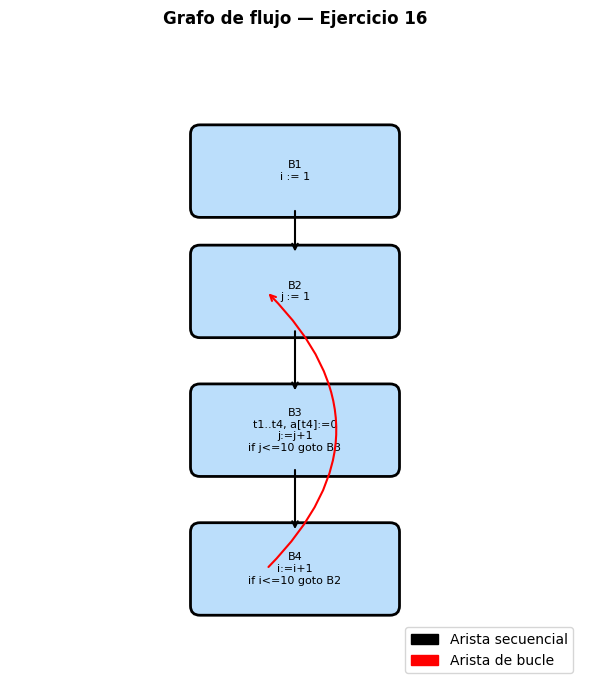

In [57]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

fig, ax = plt.subplots(figsize=(6, 7))

# Posiciones de los bloques
posiciones = {"B1": (3, 5.5), "B2": (3, 4.2), "B3": (3, 2.7), "B4": (3, 1.2)}
contenidos = {
    "B1": "B1\ni := 1",
    "B2": "B2\nj := 1",
    "B3": "B3\nt1..t4, a[t4]:=0\nj:=j+1\nif j<=10 goto B3",
    "B4": "B4\ni:=i+1\nif i<=10 goto B2",
}
for bloque, (x, y) in posiciones.items():
    ax.add_patch(mpatches.FancyBboxPatch(
        (x-1, y-0.4), 2, 0.8,
        boxstyle="round,pad=0.1", linewidth=2,
        edgecolor="black", facecolor="#bbdefb"))
    ax.text(x, y, contenidos[bloque], ha="center", va="center", fontsize=8)

# Aristas
aristas_vis = [
    ("B1", "B2", False), ("B2", "B3", False),
    ("B3", "B4", False), ("B3", "B3", True), ("B4", "B2", True),
]
for src, dst, curva in aristas_vis:
    x1, y1 = posiciones[src]
    x2, y2 = posiciones[dst]
    if not curva:
        ax.annotate("", xy=(x2, y2+0.4), xytext=(x1, y1-0.4),
                    arrowprops=dict(arrowstyle="->", color="black", lw=1.5))
    else:  # flecha curva para bucles
        ax.annotate("", xy=(x2-0.3, y2), xytext=(x1-0.3, y1),
                    arrowprops=dict(arrowstyle="->", color="red", lw=1.5,
                                   connectionstyle="arc3,rad=0.5"))

ax.set_xlim(0, 6); ax.set_ylim(0, 7)
ax.axis("off")
ax.set_title("Grafo de flujo — Ejercicio 16", fontsize=12, fontweight="bold")
bucle_patch = mpatches.Patch(color="red", label="Arista de bucle")
sec_patch   = mpatches.Patch(color="black", label="Arista secuencial")
ax.legend(handles=[sec_patch, bucle_patch], loc="lower right")
plt.tight_layout()
plt.show()

### 🔹 Ejercicio 17 — Eliminación de subexpresiones comunes (GAD)
**Enunciado:** En el siguiente bloque básico, identifica y elimina las subexpresiones comunes usando un Grafo Acíclico Dirigido (GAD).

In [58]:
# Bloque básico original
bloque_original = [
    "t1 := a + b",
    "t2 := a + b",  # subexpresión común con t1
    "t3 := t1 * c",
    "t4 := t2 * c",  # subexpresión común con t3 (t2 = t1 = a+b)
]

# El GAD detecta que t2 = t1 y que t4 = t3
# Resultado optimizado:
bloque_optimizado = [
    "t1 := a + b",   # se calcula una sola vez
    "t3 := t1 * c",  # usa t1 en lugar de recalcular a+b
]
# t2 y t4 son alias de t1 y t3 respectivamente
alias = {"t2": "t1", "t4": "t3"}

print("Bloque original:")
for i, ins in enumerate(bloque_original, 1):
    print(f"  {i}. {ins}")

print("\nSubexpresiones comunes detectadas (GAD):")
print("  t2 = a+b  (mismo valor que t1) → reutilizar t1")
print("  t4 = t2*c (mismo valor que t3) → reutilizar t3")

print("\nBloque optimizado (sin subexpresiones repetidas):")
for i, ins in enumerate(bloque_optimizado, 1):
    print(f"  {i}. {ins}")

print(f"\nAlias: {alias}")
print(f"\nAhorro: {len(bloque_original) - len(bloque_optimizado)} instrucciones eliminadas.")

Bloque original:
  1. t1 := a + b
  2. t2 := a + b
  3. t3 := t1 * c
  4. t4 := t2 * c

Subexpresiones comunes detectadas (GAD):
  t2 = a+b  (mismo valor que t1) → reutilizar t1
  t4 = t2*c (mismo valor que t3) → reutilizar t3

Bloque optimizado (sin subexpresiones repetidas):
  1. t1 := a + b
  2. t3 := t1 * c

Alias: {'t2': 't1', 't4': 't3'}

Ahorro: 2 instrucciones eliminadas.


### 🔹 Ejercicio 18 — Propagación de copias
**Enunciado:** Aplica la optimización de **propagación de copias** al siguiente bloque básico.

In [59]:
# Bloque básico original con asignaciones de copia
bloque = [
    ("x", ":=", "y",  None),    # x := y  (copia)
    ("z", ":=", "x",  None),    # z := x  → se puede reemplazar x por y
    ("w", "+",  "x",  "z"),     # w := x + z → reemplazar x por y, z por y
]

# Tabla de propagación de copias
copias = {}  # mapea nombre → valor copiado

print("Propagación de copias paso a paso:\n")
for dest, op, arg1, arg2 in bloque:
    arg1_orig = arg1
    arg2_orig = arg2
    # Sustituir operandos por sus copias
    arg1_sust = copias.get(arg1, arg1)
    arg2_sust = copias.get(arg2, arg2) if arg2 else arg2

    if op == ":=":
        copias[dest] = copias.get(arg1, arg1)  # registrar la copia
        print(f"  {dest} := {arg1_sust}   → copia registrada: {dest} = {arg1_sust}")
    else:
        print(f"  {dest} := {arg1_sust} {op} {arg2_sust}   "
              f"(antes: {arg1_orig} {op} {arg2_orig})")

print(f"\nTabla de copias final: {copias}")

Propagación de copias paso a paso:

  x := y   → copia registrada: x = y
  z := y   → copia registrada: z = y
  w := y + y   (antes: x + z)

Tabla de copias final: {'x': 'y', 'z': 'y'}


### 🔹 Ejercicio 19 — Eliminación de código muerto
**Enunciado:** Identifica y elimina el **código muerto** en el siguiente bloque básico (variables calculadas pero nunca usadas).

In [60]:
# Instrucciones: (destino, expresión, es_salida)
# es_salida=True: el valor de 'destino' es necesario fuera del bloque
instrucciones = [
    {"dest": "t1", "expr": "a + b",  "es_salida": False},
    {"dest": "t2", "expr": "t1 * c", "es_salida": False},
    {"dest": "t3", "expr": "x - y",  "es_salida": False},  # t3 nunca se usa
    {"dest": "z",  "expr": "t2 + 1", "es_salida": True},   # z se usa fuera
]

def eliminar_codigo_muerto(instrucciones):
    # Variables usadas (como operando) o de salida
    usados = set()
    for ins in instrucciones:
        if ins["es_salida"]:
            usados.add(ins["dest"])
        for token in ins["expr"].split():
            if token.isidentifier():
                usados.add(token)

    vivos   = [i for i in instrucciones if i["dest"] in usados]
    muertos = [i for i in instrucciones if i["dest"] not in usados]
    return vivos, muertos

vivos, muertos = eliminar_codigo_muerto(instrucciones)

print("Instrucciones VIVAS (se conservan):")
for i in vivos:
    salida = "← SALIDA" if i["es_salida"] else ""
    print(f"  {i['dest']} := {i['expr']}  {salida}")

print("\nInstrucciones MUERTAS (se eliminan):")
for i in muertos:
    print(f"  {i['dest']} := {i['expr']}  ← código muerto")

Instrucciones VIVAS (se conservan):
  t1 := a + b  
  t2 := t1 * c  
  z := t2 + 1  ← SALIDA

Instrucciones MUERTAS (se eliminan):
  t3 := x - y  ← código muerto


### 🔹 Ejercicio 20 — Plegado de constantes (Constant Folding)
**Enunciado:** Implementa el plegado de constantes: evalúa en tiempo de compilación las expresiones cuyos operandos son constantes conocidas.

In [61]:
def plegar_constantes(instrucciones):
    """
    instrucciones: lista de dicts con claves 'dest', 'op', 'arg1', 'arg2'.
    Devuelve la lista optimizada.
    """
    constantes = {}  # nombres con valor constante conocido
    resultado = []

    for ins in instrucciones:
        a1 = constantes.get(ins["arg1"], ins["arg1"])
        a2 = constantes.get(ins["arg2"], ins["arg2"]) if ins["arg2"] is not None else None

        # Si ambos operandos son constantes numéricas
        try:
            v1 = float(a1)
            v2 = float(a2) if a2 is not None else None
            if ins["op"] == "+" and v2 is not None:
                val = v1 + v2
            elif ins["op"] == "*" and v2 is not None:
                val = v1 * v2
            elif ins["op"] == "-" and v2 is not None:
                val = v1 - v2
            elif ins["op"] == ":=":
                val = v1
            else:
                raise ValueError
            constantes[ins["dest"]] = int(val) if val == int(val) else val
            resultado.append({**ins, "plegado": True, "valor": constantes[ins["dest"]]})
        except (ValueError, TypeError):
            resultado.append({**ins, "plegado": False})

    return resultado, constantes

instrucciones = [
    {"dest": "t1", "op": "+",  "arg1": "3",  "arg2": "4"},  # t1 = 3+4 = 7
    {"dest": "t2", "op": "*",  "arg1": "t1", "arg2": "2"},  # t2 = 7*2 = 14
    {"dest": "t3", "op": "+",  "arg1": "t2", "arg2": "x"},  # no se puede plegar (x es variable)
]

resultado, constantes = plegar_constantes(instrucciones)

print(f"{'Instrucción original':<28} {'Resultado'}")
print("-" * 55)
for ins in resultado:
    orig = f"{ins['dest']} := {ins['arg1']} {ins['op']} {ins['arg2']}"
    if ins["plegado"]:
        print(f"  {orig:<26}  → {ins['dest']} = {ins['valor']}  (plegado)")
    else:
        print(f"  {orig:<26}  → sin cambio (variable no constante)")

Instrucción original         Resultado
-------------------------------------------------------
  t1 := 3 + 4                 → t1 = 7  (plegado)
  t2 := t1 * 2                → t2 = 14  (plegado)
  t3 := t2 + x                → sin cambio (variable no constante)


### 🔹 Ejercicio 21 — ¿Es este bloque básico? Verificación
**Enunciado:** Escribe una función que verifique si una secuencia de instrucciones forma un bloque básico válido.

In [62]:
def es_bloque_basico(instrucciones):
    """
    Verifica las dos condiciones:
    1. Solo la primera instrucción puede ser destino de un salto (líder).
    2. Solo la última instrucción puede ser un salto o una bifurcación.
    """
    if not instrucciones:
        return False, "Lista vacía"

    # Verificar que ninguna instrucción intermedia es un salto
    for i, instr in enumerate(instrucciones[:-1]):  # todas menos la última
        if "goto" in instr or "if" in instr:
            return False, f"Salto en instrucción intermedia #{i+1}: '{instr}'"

    return True, "Es un bloque básico válido."

casos = [
    ["x := a + b", "y := x * c", "z := y - 1"],                    # válido
    ["x := a + b", "if x > 0 goto L1", "y := x * c"],              # inválido (salto intermedio)
    ["x := a + b", "y := x * c", "if y > 0 goto L2"],              # válido (salto al final)
]

for idx, bloque in enumerate(casos, 1):
    valido, msg = es_bloque_basico(bloque)
    print(f"Caso {idx}: {'✅ VÁLIDO' if valido else '❌ NO VÁLIDO'}  —  {msg}")
    for ins in bloque:
        print(f"  • {ins}")
    print()

Caso 1: ✅ VÁLIDO  —  Es un bloque básico válido.
  • x := a + b
  • y := x * c
  • z := y - 1

Caso 2: ❌ NO VÁLIDO  —  Salto en instrucción intermedia #2: 'if x > 0 goto L1'
  • x := a + b
  • if x > 0 goto L1
  • y := x * c

Caso 3: ✅ VÁLIDO  —  Es un bloque básico válido.
  • x := a + b
  • y := x * c
  • if y > 0 goto L2



### 🔹 Ejercicio 22 — Análisis de vida útil (Liveness)
**Enunciado:** Dado un bloque básico, calcula qué variables están **vivas** (se usarán después) en cada punto del programa.

In [63]:
# Representación: lista de (definido, usados_en_esta_instrucción)
bloque = [
    ("t1", {"a", "b"}),    # t1 := a + b
    ("t2", {"t1", "c"}),   # t2 := t1 * c
    ("t3", {"t2", "d"}),   # t3 := t2 + d
    ("x",  {"t3"}),        # x  := t3     ← salida del bloque
]

# Variables vivas a la SALIDA del bloque (se usan fuera)
vivas_salida = {"x"}

# Análisis hacia atrás (backward analysis)
vivas = vivas_salida.copy()
print("Análisis de vida útil (de abajo hacia arriba):\n")
print(f"  {'Instrucción':<25} {'Vivas ANTES (live-in)'}")
print("-" * 55)

estados = []
for definido, usados in reversed(bloque):
    # live_in = (live_out - {definido}) ∪ usados
    vivas = (vivas - {definido}) | usados
    estados.append((definido, usados, frozenset(vivas)))

for definido, usados, vivas_antes in reversed(estados):
    instr = f"{definido} := {' op '.join(sorted(usados))}"
    print(f"  {instr:<25} {sorted(vivas_antes)}")

print(f"\n  Variables vivas a la SALIDA: {sorted(vivas_salida)}")

Análisis de vida útil (de abajo hacia arriba):

  Instrucción               Vivas ANTES (live-in)
-------------------------------------------------------
  t1 := a op b              ['a', 'b', 'c', 'd']
  t2 := c op t1             ['c', 'd', 't1']
  t3 := d op t2             ['d', 't2']
  x := t3                   ['t3']

  Variables vivas a la SALIDA: ['x']


---
## 📌 Sección 4 — Generación de Código Sencillo

El generador simple procesa instrucciones de la RI una a una, apoyándose en **descriptores de registros** y **descriptores de direcciones** para tomar decisiones de asignación.

### 🔹 Ejercicio 23 — Descriptores de registros y direcciones
**Enunciado:** Inicializa los descriptores y simula la carga de la variable `a` en el registro `R0`.

In [64]:
class Descriptores:
    def __init__(self, registros):
        # desc_registro[Ri] = conjunto de variables/temporales que contiene Ri
        self.desc_reg  = {r: set() for r in registros}
        # desc_dir[var]  = conjunto de lugares donde está el valor de var (registros o 'MEM')
        self.desc_dir  = {}

    def cargar(self, registro, variable):
        """Simula: LD registro, variable"""
        self.desc_reg[registro].add(variable)
        if variable not in self.desc_dir:
            self.desc_dir[variable] = {"MEM"}  # empieza en memoria
        self.desc_dir[variable].add(registro)

    def asignar(self, registro, variable_resultado):
        """Actualiza descriptores tras una operación: registro ← resultado."""
        # Limpiar el registro de contenidos previos
        for v in list(self.desc_reg[registro]):
            self.desc_dir[v].discard(registro)
        self.desc_reg[registro] = {variable_resultado}
        self.desc_dir[variable_resultado] = {registro}  # solo en registro (pendiente de store)

    def mostrar(self):
        print("  Descriptor de registros:")
        for r, contenido in self.desc_reg.items():
            print(f"    {r}: {contenido if contenido else '(vacío)'}")
        print("  Descriptor de direcciones:")
        for v, locs in self.desc_dir.items():
            print(f"    {v}: {locs}")

# Simulación
desc = Descriptores(["R0", "R1", "R2"])

print("[Estado inicial]")
desc.mostrar()

print("\n→ Ejecutamos: LD R0, a")
desc.cargar("R0", "a")

print("\n[Después de LD R0, a]")
desc.mostrar()

[Estado inicial]
  Descriptor de registros:
    R0: (vacío)
    R1: (vacío)
    R2: (vacío)
  Descriptor de direcciones:

→ Ejecutamos: LD R0, a

[Después de LD R0, a]
  Descriptor de registros:
    R0: {'a'}
    R1: (vacío)
    R2: (vacío)
  Descriptor de direcciones:
    a: {'R0', 'MEM'}


### 🔹 Ejercicio 24 — Función getReg simplificada
**Enunciado:** Implementa una versión simplificada de `getReg` que elige el primer registro libre para un operando.

In [65]:
def get_reg(variable, desc_reg, desc_dir):
    """
    Devuelve el registro donde está 'variable'.
    Si no está en ningún registro, asigna el primer registro libre
    y genera una instrucción LD.
    """
    # ¿Ya está en un registro?
    for reg, contenido in desc_reg.items():
        if variable in contenido:
            print(f"    getReg('{variable}'): ya está en {reg} — sin carga necesaria")
            return reg, []

    # Buscar registro libre
    for reg, contenido in desc_reg.items():
        if not contenido:
            instrucciones_gen = [f"LD  {reg}, {variable}"]
            desc_reg[reg].add(variable)
            desc_dir.setdefault(variable, set()).add(reg)
            print(f"    getReg('{variable}'): asignado a {reg} — genera: {instrucciones_gen[0]}")
            return reg, instrucciones_gen

    print(f"    getReg('{variable}'): ¡sin registros libres! (spill no implementado)")
    return None, []

# Estado de los descriptores
desc_reg = {"R0": set(), "R1": set(), "R2": set()}
desc_dir = {}

print("Simulación de getReg para: t1 := a + b\n")
reg_a, ins_a = get_reg("a", desc_reg, desc_dir)
reg_b, ins_b = get_reg("b", desc_reg, desc_dir)

# Generar instrucción ADD
reg_dest = "R2"
ins_op = f"ADD {reg_dest}, {reg_a}, {reg_b}"
print(f"    Instrucción generada: {ins_op}")

print("\nCódigo generado:")
for ins in ins_a + ins_b + [ins_op]:
    print(f"  {ins}")

Simulación de getReg para: t1 := a + b

    getReg('a'): asignado a R0 — genera: LD  R0, a
    getReg('b'): asignado a R1 — genera: LD  R1, b
    Instrucción generada: ADD R2, R0, R1

Código generado:
  LD  R0, a
  LD  R1, b
  ADD R2, R0, R1


### 🔹 Ejercicio 25 — Generación de código para una instrucción aritmética
**Enunciado:** Genera código máquina para la instrucción RI `t1 := a - b`, actualizando los descriptores correctamente.

In [66]:
def generar_aritmetica(dest, op_ri, arg1, arg2, desc_reg, desc_dir):
    """Genera instrucciones para: dest := arg1 op_ri arg2"""
    codigo = []
    # Cargar operandos
    for var, reg_slot in [(arg1, "R0"), (arg2, "R1")]:
        ya_en_reg = any(var in c for c in desc_reg.values())
        if not ya_en_reg:
            codigo.append(f"LD  {reg_slot}, {var}")
            desc_reg[reg_slot] = {var}
            desc_dir.setdefault(var, set()).add(reg_slot)

    # Determinar registros de los operandos
    def reg_de(v):
        for r, c in desc_reg.items():
            if v in c: return r
        return None

    r1, r2 = reg_de(arg1), reg_de(arg2)
    r_dest = "R2"

    # Mapear operador RI → mnemónico ISA
    mapa_op = {"+": "ADD", "-": "SUB", "*": "MUL"}
    mnem = mapa_op.get(op_ri, op_ri)

    codigo.append(f"{mnem} {r_dest}, {r1}, {r2}")

    # Actualizar descriptores
    desc_reg[r_dest] = {dest}
    desc_dir[dest] = {r_dest}

    return codigo

desc_reg = {"R0": set(), "R1": set(), "R2": set()}
desc_dir = {}

codigo = generar_aritmetica("t1", "-", "a", "b", desc_reg, desc_dir)

print("RI: t1 := a - b")
print("\nCódigo generado:")
for ins in codigo:
    print(f"  {ins}")

print("\nDescriptor de registros final:")
for r, c in desc_reg.items():
    print(f"  {r}: {c}")

RI: t1 := a - b

Código generado:
  LD  R0, a
  LD  R1, b
  SUB R2, R0, R1

Descriptor de registros final:
  R0: {'a'}
  R1: {'b'}
  R2: {'t1'}


### 🔹 Ejercicio 26 — Generación de código para asignación simple
**Enunciado:** Genera código para `a := b`, que es una copia simple entre variables.

In [67]:
def generar_copia(dest, fuente, desc_reg, desc_dir):
    """Genera instrucciones para: dest := fuente"""
    codigo = []
    # Verificar si fuente ya está en un registro
    reg_fuente = None
    for r, contenido in desc_reg.items():
        if fuente in contenido:
            reg_fuente = r
            break

    if reg_fuente is None:
        # Cargar fuente en un registro
        reg_fuente = "R0"
        codigo.append(f"LD  {reg_fuente}, {fuente}")
        desc_reg[reg_fuente] = {fuente}
        desc_dir.setdefault(fuente, {"MEM"}).add(reg_fuente)

    # El destino ahora tiene el mismo valor que fuente
    # Opción A: solo actualizar descriptores (sin instrucción extra si no hay necesidad de almacenar)
    desc_reg[reg_fuente].add(dest)  # reg_fuente ahora contiene también 'dest'
    desc_dir[dest] = {reg_fuente}

    print(f"  → dest '{dest}' ahora comparte registro {reg_fuente} con '{fuente}'")

    return codigo

desc_reg = {"R0": set(), "R1": set()}
desc_dir = {}

print("RI: a := b")
codigo = generar_copia("a", "b", desc_reg, desc_dir)

print("\nInstrucciones generadas:")
if codigo:
    for ins in codigo:
        print(f"  {ins}")
else:
    print("  (ninguna instrucción adicional si a y b comparten registro)")

print("\nDescriptor de registros:")
for r, c in desc_reg.items():
    if c: print(f"  {r}: {c}")

RI: a := b
  → dest 'a' ahora comparte registro R0 con 'b'

Instrucciones generadas:
  LD  R0, b

Descriptor de registros:
  R0: {'a', 'b'}


### 🔹 Ejercicio 27 — Generación de código para instrucción condicional
**Enunciado:** Genera código máquina para `if x < y goto L1`.

In [68]:
def generar_condicional(op1, comparador, op2, etiqueta):
    """
    Genera código para: if op1 comparador op2 goto etiqueta
    Retorna lista de instrucciones.
    """
    # Mapear comparador a instrucción de salto
    mapa_salto = {
        "<":  "BLT",   # Branch if Less Than
        "<=": "BLE",   # Branch if Less or Equal
        ">": "BGT",    # Branch if Greater Than
        ">=": "BGE",   # Branch if Greater or Equal
        "==": "BEQ",   # Branch if Equal
        "!=": "BNE",   # Branch if Not Equal
    }
    salto = mapa_salto.get(comparador, "B??")

    instrucciones = [
        f"LD  R0, {op1}        ; cargar {op1}",
        f"LD  R1, {op2}        ; cargar {op2}",
        f"SUB R2, R0, R1       ; R2 = {op1} - {op2} (comparación)",
        f"{salto} R2, {etiqueta}       ; si {op1} {comparador} {op2} salta a {etiqueta}",
    ]
    return instrucciones

print("RI: if x < y goto L1")
print("\nCódigo generado:")
for i, ins in enumerate(generar_condicional("x", "<", "y", "L1"), 1):
    print(f"  {i}. {ins}")

print("\n" + "="*50)
print("RI: if a == b goto L2")
print("\nCódigo generado:")
for i, ins in enumerate(generar_condicional("a", "==", "b", "L2"), 1):
    print(f"  {i}. {ins}")

RI: if x < y goto L1

Código generado:
  1. LD  R0, x        ; cargar x
  2. LD  R1, y        ; cargar y
  3. SUB R2, R0, R1       ; R2 = x - y (comparación)
  4. BLT R2, L1       ; si x < y salta a L1

RI: if a == b goto L2

Código generado:
  1. LD  R0, a        ; cargar a
  2. LD  R1, b        ; cargar b
  3. SUB R2, R0, R1       ; R2 = a - b (comparación)
  4. BEQ R2, L2       ; si a == b salta a L2


### 🔹 Ejercicio 28 — Store al final del bloque básico
**Enunciado:** Al final de un bloque básico, genera las instrucciones `ST` para almacenar en memoria las variables vivas cuyos valores solo están en registros.

In [69]:
def generar_stores_finales(desc_reg, desc_dir, vivas_salida):
    """
    Genera instrucciones ST para variables vivas que solo están en registros.
    """
    stores = []
    for var in vivas_salida:
        ubicaciones = desc_dir.get(var, {"MEM"})
        # Si el valor solo está en un registro (no en memoria)
        registros = [loc for loc in ubicaciones if loc != "MEM"]
        en_memoria = "MEM" in ubicaciones
        if registros and not en_memoria:
            stores.append(f"ST  {var}, {registros[0]}   ; guardar '{var}' en memoria")

    return stores

# Simular estado tras procesar un bloque básico
desc_reg = {"R0": {"x"}, "R1": {"y"}, "R2": {"z"}}
desc_dir = {
    "x": {"R0"},         # x solo en R0 → necesita ST
    "y": {"R1", "MEM"},  # y en R1 y en memoria → no necesita ST
    "z": {"R2"},         # z solo en R2 → necesita ST
}
vivas_salida = {"x", "z"}  # y no está viva a la salida

stores = generar_stores_finales(desc_reg, desc_dir, vivas_salida)

print("Variables vivas a la salida del bloque:", vivas_salida)
print("\nInstrucciones ST generadas al final del bloque:")
if stores:
    for s in stores:
        print(f"  {s}")
else:
    print("  (ninguna: todos los valores ya están en memoria)")

Variables vivas a la salida del bloque: {'z', 'x'}

Instrucciones ST generadas al final del bloque:
  ST  z, R2   ; guardar 'z' en memoria
  ST  x, R0   ; guardar 'x' en memoria


### 🔹 Ejercicio 29 — Generación de código para un bloque básico completo
**Enunciado:** Genera código máquina para el bloque básico: `t1 := a + b`, `t2 := t1 * c`, `x := t2`.

In [70]:
# Bloque básico RI
bloque_RI = [
    ("t1", "+", "a",  "b"),
    ("t2", "*", "t1", "c"),
    ("x",  ":=","t2", None),  # asignación
]

# Registros disponibles
registros = ["R0", "R1", "R2", "R3"]
desc_reg = {r: set() for r in registros}
desc_dir = {}

mapa_op = {"+": "ADD", "-": "SUB", "*": "MUL"}
codigo_total = []

def registro_libre(excluir=()):
    """Devuelve el primer registro vacío que no esté en 'excluir'."""
    for r, contenido in desc_reg.items():
        if not contenido and r not in excluir:
            return r
    raise RuntimeError("Sin registros libres (spill no implementado)")

def asignar_registro(var):
    """Devuelve el registro donde está var o busca uno libre y genera LD."""
    # ¿ya está en algún registro?
    for r, c in desc_reg.items():
        if var in c:
            return r, []
    # Buscar el primer registro vacío
    r = registro_libre()
    ins = f"LD  {r}, {var}"
    desc_reg[r] = {var}
    desc_dir.setdefault(var, {"MEM"}).add(r)
    return r, [ins]

for dest, op, arg1, arg2 in bloque_RI:
    if op == ":=":
        r_src, ins = asignar_registro(arg1)
        codigo_total.extend(ins)
        # dest comparte registro con arg1
        desc_reg[r_src].add(dest)
        desc_dir[dest] = {r_src}
    else:
        r1, ins1 = asignar_registro(arg1)
        r2, ins2 = asignar_registro(arg2)
        codigo_total.extend(ins1 + ins2)
        # Elegir registro destino libre (distinto de r1 y r2)
        # Si r1 ya no se necesita después, reutilizarlo como destino
        usos_futuros = {a for (_, _, a1, a2) in bloque_RI[bloque_RI.index((dest, op, arg1, arg2))+1:]
                        for a in (a1, a2) if a}
        if arg1 not in usos_futuros:
            r_dest = r1                      # reutilizar registro de arg1
            desc_reg[r_dest] = {dest}        # ya no contiene arg1
        else:
            r_dest = registro_libre(excluir=(r1, r2))
        mnem = mapa_op[op]
        codigo_total.append(f"{mnem} {r_dest}, {r1}, {r2}")
        desc_reg[r_dest] = {dest}
        desc_dir[dest] = {r_dest}

# Store final para x (variable de salida)
r_x = list(desc_dir["x"])[0]
codigo_total.append(f"ST  x, {r_x}")

print("Bloque RI de entrada:")
for d, op, a1, a2 in bloque_RI:
    print(f"  {d} := {a1} {op} {a2 or ''}")

print("\nCódigo máquina generado:")
for i, ins in enumerate(codigo_total, 1):
    print(f"  {i:>2}. {ins}")

Bloque RI de entrada:
  t1 := a + b
  t2 := t1 * c
  x := t2 := 

Código máquina generado:
   1. LD  R0, a
   2. LD  R1, b
   3. ADD R0, R0, R1
   4. LD  R2, c
   5. MUL R0, R0, R2
   6. ST  x, R0


### 🔹 Ejercicio 30 — Trace del generador de código simple
**Enunciado:** Muestra el estado de los descriptores instrucción por instrucción mientras se genera código para `t1 := a + b`.

In [71]:
def trazar_generacion(instruccion_ri):
    dest, op, arg1, arg2 = instruccion_ri
    desc_reg = {"R0": set(), "R1": set(), "R2": set()}
    desc_dir = {}
    pasos = []

    def snapshot(accion):
        pasos.append({
            "acción": accion,
            "desc_reg": {k: set(v) for k, v in desc_reg.items()},
            "desc_dir": {k: set(v) for k, v in desc_dir.items()},
        })

    snapshot("Estado inicial")

    # Paso 1: cargar arg1
    desc_reg["R0"] = {arg1}; desc_dir[arg1] = {"MEM", "R0"}
    snapshot(f"LD R0, {arg1}")

    # Paso 2: cargar arg2
    desc_reg["R1"] = {arg2}; desc_dir[arg2] = {"MEM", "R1"}
    snapshot(f"LD R1, {arg2}")

    # Paso 3: operación
    mnem = {"+": "ADD", "-": "SUB", "*": "MUL"}[op]
    desc_reg["R2"] = {dest}; desc_dir[dest] = {"R2"}
    snapshot(f"{mnem} R2, R0, R1")

    # Mostrar traza
    print(f"Traza para: {dest} := {arg1} {op} {arg2}\n")
    for p in pasos:
        print(f"  [{p['acción']}]")
        print(f"    desc_reg: { {k:v for k,v in p['desc_reg'].items() if v} }")
        print(f"    desc_dir: { p['desc_dir'] }")
        print()

trazar_generacion(("t1", "+", "a", "b"))

Traza para: t1 := a + b

  [Estado inicial]
    desc_reg: {}
    desc_dir: {}

  [LD R0, a]
    desc_reg: {'R0': {'a'}}
    desc_dir: {'a': {'R0', 'MEM'}}

  [LD R1, b]
    desc_reg: {'R0': {'a'}, 'R1': {'b'}}
    desc_dir: {'a': {'R0', 'MEM'}, 'b': {'MEM', 'R1'}}

  [ADD R2, R0, R1]
    desc_reg: {'R0': {'a'}, 'R1': {'b'}, 'R2': {'t1'}}
    desc_dir: {'a': {'R0', 'MEM'}, 'b': {'MEM', 'R1'}, 't1': {'R2'}}



---
## 📌 Sección 5 — Uso Eficiente de Registros

La **asignación global de registros** decide, para todo el programa, qué variables conviene mantener en registros. El algoritmo de **coloreado de grafos** es el método estándar para abordar este problema.

### 🔹 Ejercicio 31 — Grafo de interferencia
**Enunciado:** Dadas las vidas útiles de cuatro variables, construye el grafo de interferencia.

In [72]:
# Rango de vida: {variable: conjunto de puntos del programa en que está viva}
# (representamos los puntos como enteros)
vida_util = {
    "a": {1, 2, 3},
    "b": {2, 3, 4},
    "c": {5, 6},
    "d": {3, 4, 5},
}

def construir_grafo_interferencia(vida):
    """Dos variables interfieren si sus vidas útiles se solapan."""
    variables = list(vida.keys())
    aristas = set()
    for i in range(len(variables)):
        for j in range(i+1, len(variables)):
            v1, v2 = variables[i], variables[j]
            if vida[v1] & vida[v2]:  # intersección no vacía
                aristas.add((v1, v2))
    return variables, aristas

variables, aristas = construir_grafo_interferencia(vida_util)

print("Grafo de interferencia:")
print(f"  Nodos (variables): {variables}")
print(f"  Aristas (interferencias):")
for v1, v2 in sorted(aristas):
    solapamiento = vida_util[v1] & vida_util[v2]
    print(f"    {v1} ── {v2}  (solapan en puntos {sorted(solapamiento)})")

print("\nVariables que NO interfieren (pueden compartir registro):")
for i in range(len(variables)):
    for j in range(i+1, len(variables)):
        v1, v2 = variables[i], variables[j]
        if (v1, v2) not in aristas and (v2, v1) not in aristas:
            print(f"    {v1} y {v2}")

Grafo de interferencia:
  Nodos (variables): ['a', 'b', 'c', 'd']
  Aristas (interferencias):
    a ── b  (solapan en puntos [2, 3])
    a ── d  (solapan en puntos [3])
    b ── d  (solapan en puntos [3, 4])
    c ── d  (solapan en puntos [5])

Variables que NO interfieren (pueden compartir registro):
    a y c
    b y c


### 🔹 Ejercicio 32 — Colorear el grafo (asignar registros)
**Enunciado:** Aplica el algoritmo de coloreado voraz al grafo de interferencia anterior usando `k=2` colores (registros).

In [73]:
def colorear_grafo(variables, aristas, k):
    """
    Coloreo voraz: asigna el menor color posible a cada nodo
    que no esté siendo usado por sus vecinos.
    Retorna: {variable: color} y lista de variables a derramar.
    """
    # Construir lista de adyacencia
    adj = {v: set() for v in variables}
    for v1, v2 in aristas:
        adj[v1].add(v2)
        adj[v2].add(v1)

    colores  = {}   # variable → color (nº de registro)
    derramar = []   # variables que no caben en k registros

    for var in variables:
        colores_usados = {colores.get(v) for v in adj[var] if v in colores}
        # Asignar el menor color libre
        color = 0
        while color in colores_usados:
            color += 1
        if color < k:
            colores[var] = color
        else:
            derramar.append(var)

    return colores, derramar

# Usar grafo del ejercicio anterior
variables = ["a", "b", "c", "d"]
aristas = [("a","b"), ("a","d"), ("b","d"), ("c","d")]
k = 2  # 2 registros disponibles

colores, derramar = colorear_grafo(variables, aristas, k)

print(f"Coloreado con k={k} registros:\n")
registros_nombre = ["R0", "R1", "R2"]
for var, color in colores.items():
    print(f"  {var}  →  {registros_nombre[color]}  (color {color})")

if derramar:
    print(f"\n  Variables a DERRAMAR a memoria: {derramar}")
else:
    print(f"\n  ✅ Todas las variables caben en {k} registros.")

Coloreado con k=2 registros:

  a  →  R0  (color 0)
  b  →  R1  (color 1)
  c  →  R0  (color 0)

  Variables a DERRAMAR a memoria: ['d']


### 🔹 Ejercicio 33 — Visualización del grafo de interferencia
**Enunciado:** Visualiza el grafo de interferencia con los colores asignados en el ejercicio anterior.

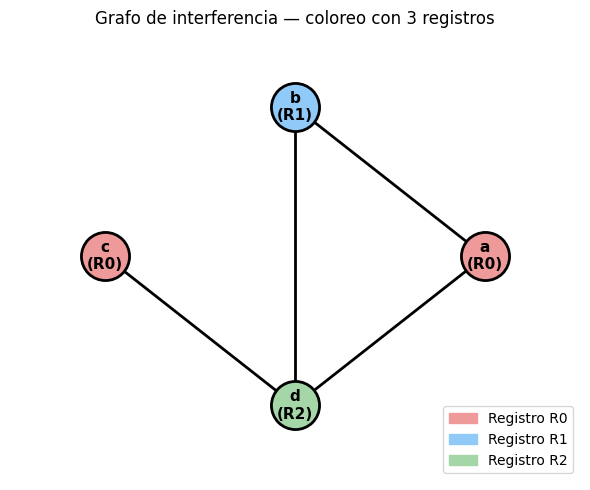

In [74]:
import matplotlib.pyplot as plt
import numpy as np

# Datos del grafo
variables = ["a", "b", "c", "d"]
aristas   = [("a","b"), ("a","d"), ("b","d"), ("c","d")]
# Colores del ejercicio 32 (a=R0, b=R1, c=R0, d=R0... revisar con k=3)
# Para visualización, usamos k=3
colores_ej, _ = colorear_grafo(variables, aristas, k=3)
paleta = ["#ef9a9a", "#90caf9", "#a5d6a7"]  # rojo, azul, verde

# Posiciones en círculo
angulos = np.linspace(0, 2*np.pi, len(variables), endpoint=False)
pos = {v: (np.cos(a), np.sin(a)) for v, a in zip(variables, angulos)}

fig, ax = plt.subplots(figsize=(6, 5))

# Dibujar aristas
for v1, v2 in aristas:
    x1, y1 = pos[v1]; x2, y2 = pos[v2]
    ax.plot([x1, x2], [y1, y2], "k-", linewidth=2, zorder=1)

# Dibujar nodos
for var in variables:
    x, y = pos[var]
    color = paleta[colores_ej.get(var, 2)]
    reg   = ["R0", "R1", "R2"][colores_ej.get(var, 2)]
    ax.scatter(x, y, s=1200, color=color, edgecolors="black", linewidth=2, zorder=2)
    ax.text(x, y, f"{var}\n({reg})", ha="center", va="center", fontsize=11, fontweight="bold")

ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
ax.axis("off")
ax.set_title("Grafo de interferencia — coloreo con 3 registros", fontsize=12)

patches = [plt.matplotlib.patches.Patch(color=paleta[i], label=f"Registro R{i}")
           for i in range(3)]
ax.legend(handles=patches, loc="lower right")
plt.tight_layout()
plt.show()

### 🔹 Ejercicio 34 — Algoritmo de simplificación (Chaitin)
**Enunciado:** Implementa el paso de **simplificación** del algoritmo de Chaitin: retira nodos con grado < k hasta vaciar el grafo.

In [75]:
def simplificar_chaitin(variables, aristas, k):
    """
    Fase de simplificación del algoritmo de Chaitin.
    Retira nodos de grado < k y los apila.
    Si todos los nodos tienen grado >= k, elige un candidato a derramar.
    """
    # Construir grafo
    adj = {v: set() for v in variables}
    for v1, v2 in aristas:
        adj[v1].add(v2); adj[v2].add(v1)

    pila    = []   # orden en que se colorearán
    derramar = []
    restantes = set(variables)

    print(f"Simplificación con k={k} registros:\n")

    while restantes:
        # Buscar nodo con grado < k
        candidato = None
        for v in restantes:
            grado = len(adj[v] & restantes)
            if grado < k:
                candidato = v
                break

        if candidato:
            grado_actual = len(adj[candidato] & restantes)
            print(f"  Simplificar: retirar '{candidato}' (grado={grado_actual} < k={k}) → pila")
            pila.append(candidato)
        else:
            # Derramar el nodo de mayor grado
            candidato = max(restantes, key=lambda v: len(adj[v] & restantes))
            grado_actual = len(adj[candidato] & restantes)
            print(f"  ¡Spill! derramar '{candidato}' (grado={grado_actual} >= k={k})")
            derramar.append(candidato)
            pila.append(candidato)

        restantes.remove(candidato)

    print(f"\n  Orden de la pila (colorear de arriba abajo): {list(reversed(pila))}")
    print(f"  Variables a derramar: {derramar if derramar else 'ninguna'}")
    return pila, derramar

variables = ["a", "b", "c", "d"]
aristas   = [("a","b"), ("a","d"), ("b","d"), ("c","d")]
pila, derramar = simplificar_chaitin(variables, aristas, k=2)

Simplificación con k=2 registros:

  Simplificar: retirar 'c' (grado=1 < k=2) → pila
  ¡Spill! derramar 'a' (grado=2 >= k=2)
  Simplificar: retirar 'd' (grado=1 < k=2) → pila
  Simplificar: retirar 'b' (grado=0 < k=2) → pila

  Orden de la pila (colorear de arriba abajo): ['b', 'd', 'a', 'c']
  Variables a derramar: ['a']


### 🔹 Ejercicio 35 — Impacto del derramamiento (spill)
**Enunciado:** Muestra el código que se debe insertar cuando una variable es derramada a memoria (antes de cada uso y después de cada definición).

In [76]:
# Instrucciones originales que usan la variable 'd' (que fue derramada)
instrucciones_orig = [
    "ADD R0, R1, Rd    ; usa d",
    "MUL R2, Rd, R3   ; usa d",
    "MOV Rd, R0       ; define d",
]

def insertar_spill_code(instrucciones, var_spill, dir_mem):
    """
    Para cada instrucción que usa o define la variable en spill,
    inserta LD antes del uso y ST después de la definición.
    """
    reg_spill = "Rd"  # el registro temporal asignado a d
    resultado = []
    for ins in instrucciones:
        usa_var   = reg_spill in ins and "define" not in ins
        define_var = "define" in ins

        if usa_var:
            resultado.append(f"LD  {reg_spill}, {dir_mem}  ; SPILL: cargar {var_spill} desde mem")
        resultado.append(ins)
        if define_var:
            resultado.append(f"ST  {dir_mem}, {reg_spill}  ; SPILL: guardar {var_spill} en mem")
    return resultado

print("Instrucciones ORIGINALES (d en registro Rd):")
for ins in instrucciones_orig:
    print(f"  {ins}")

print("\nInstrucciones CON SPILL CODE (d en memoria en 'mem_d'):")
resultado = insertar_spill_code(instrucciones_orig, "d", "mem_d")
for ins in resultado:
    marca = "  ← spill" if "SPILL" in ins else ""
    print(f"  {ins}{marca}")

print(f"\nCosto adicional: {resultado.count('SPILL')} instrucciones extra "
      f"(accesos a memoria).")

Instrucciones ORIGINALES (d en registro Rd):
  ADD R0, R1, Rd    ; usa d
  MUL R2, Rd, R3   ; usa d
  MOV Rd, R0       ; define d

Instrucciones CON SPILL CODE (d en memoria en 'mem_d'):
  LD  Rd, mem_d  ; SPILL: cargar d desde mem  ← spill
  ADD R0, R1, Rd    ; usa d
  LD  Rd, mem_d  ; SPILL: cargar d desde mem  ← spill
  MUL R2, Rd, R3   ; usa d
  MOV Rd, R0       ; define d
  ST  mem_d, Rd  ; SPILL: guardar d en mem  ← spill

Costo adicional: 0 instrucciones extra (accesos a memoria).


### 🔹 Ejercicio 36 — Comparación: asignación local vs global
**Enunciado:** Compara el número de instrucciones generadas para un bucle usando asignación local (por bloque) vs asignación global (variable `i` siempre en registro).

Instrucciones por iteración:
  Asignación LOCAL:   5 instrucciones
  Asignación GLOBAL:  2 instrucciones

Total en 10 iteraciones:
  LOCAL:  50
  GLOBAL: 20
  Ahorro: 30 instrucciones (60% menos)


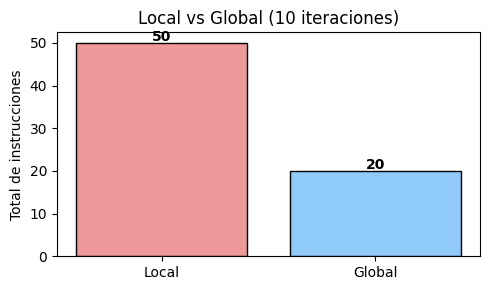

In [77]:
import matplotlib.pyplot as plt

N_ITERACIONES = 10  # número de iteraciones del bucle

# Asignación LOCAL: cada bloque carga y guarda 'i'
instrucciones_por_iter_local = [
    "LD R0, i       ; cargar i",
    "ADD R0, R0, #1 ; i++",
    "ST i, R0       ; guardar i",
    "LD R0, i       ; cargar i para la comparación",
    "BLT R0, #10, LOOP",
]

# Asignación GLOBAL: 'i' siempre en R0
instrucciones_por_iter_global = [
    "ADD R0, R0, #1 ; i++ (i siempre en R0)",
    "BLT R0, #10, LOOP",
]

total_local  = len(instrucciones_por_iter_local)  * N_ITERACIONES
total_global = len(instrucciones_por_iter_global) * N_ITERACIONES

print("Instrucciones por iteración:")
print(f"  Asignación LOCAL:  {len(instrucciones_por_iter_local):>2} instrucciones")
print(f"  Asignación GLOBAL: {len(instrucciones_por_iter_global):>2} instrucciones")
print(f"\nTotal en {N_ITERACIONES} iteraciones:")
print(f"  LOCAL:  {total_local}")
print(f"  GLOBAL: {total_global}")
print(f"  Ahorro: {total_local - total_global} instrucciones "
      f"({(1 - total_global/total_local)*100:.0f}% menos)")

# Gráfica comparativa
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(["Local", "Global"], [total_local, total_global],
       color=["#ef9a9a", "#90caf9"], edgecolor="black")
ax.set_ylabel("Total de instrucciones")
ax.set_title(f"Local vs Global ({N_ITERACIONES} iteraciones)")
for i, v in enumerate([total_local, total_global]):
    ax.text(i, v + 0.5, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

---
## 📌 Sección 6 — Optimización a Nivel de Código Máquina

Más allá de la traducción directa, el generador puede aprovechar instrucciones especializadas (modos de direccionamiento complejos, instrucciones CISC, SIMD) y usar **programación dinámica** para seleccionar la secuencia óptima.

### 🔹 Ejercicio 37 — Instrucciones especializadas CISC
**Enunciado:** Compara la implementación de `x := x + 1` usando una secuencia RISC estándar y una instrucción INC de una arquitectura CISC.

In [78]:
print("RI: x := x + 1\n")

# Implementación RISC
risc = [
    "LD  R0, x      ; cargar x (2 ciclos)",
    "ADD R0, R0, #1 ; sumar 1  (1 ciclo)",
    "ST  x, R0      ; guardar  (2 ciclos)",
]
costo_risc = 2 + 1 + 2  # ciclos

# Implementación CISC (instrucción INC directa en memoria)
cisc = [
    "INC x          ; incrementar x en memoria (1 instrucción, ~3 ciclos)",
]
costo_cisc = 3  # ciclos (internamente hace LD+ADD+ST pero en 1 instrucción)

print("--- RISC ---")
for ins in risc: print(f"  {ins}")
print(f"  Costo total: {costo_risc} ciclos, {len(risc)} instrucciones")

print("\n--- CISC ---")
for ins in cisc: print(f"  {ins}")
print(f"  Costo total: {costo_cisc} ciclos, {len(cisc)} instrucción")

print(f"\nAhorro CISC vs RISC: "
      f"{len(risc) - len(cisc)} instrucción(es) menos, "
      f"{costo_risc - costo_cisc} ciclo(s) menos")

RI: x := x + 1

--- RISC ---
  LD  R0, x      ; cargar x (2 ciclos)
  ADD R0, R0, #1 ; sumar 1  (1 ciclo)
  ST  x, R0      ; guardar  (2 ciclos)
  Costo total: 5 ciclos, 3 instrucciones

--- CISC ---
  INC x          ; incrementar x en memoria (1 instrucción, ~3 ciclos)
  Costo total: 3 ciclos, 1 instrucción

Ahorro CISC vs RISC: 2 instrucción(es) menos, 2 ciclo(s) menos


### 🔹 Ejercicio 38 — Modo de direccionamiento indexado para arreglos
**Enunciado:** Genera código optimizado para `x := a[i]` usando el modo de direccionamiento indexado en lugar de calcular la dirección explícitamente.

In [79]:
print("RI: x := a[i]  (acceso a arreglo, cada elemento ocupa 4 bytes)\n")

# Sin optimización (dirección calculada explícitamente)
sin_opt = [
    "LD  R0, i          ; cargar i",
    "MUL R0, R0, #4     ; offset = i * 4",
    "LD  R1, base_a     ; cargar dirección base de a",
    "ADD R1, R1, R0     ; dirección efectiva = base_a + offset",
    "LD  R2, (R1)       ; cargar a[i] mediante indirecto",
    "ST  x, R2          ; guardar en x",
]

# Con modo indexado (si la máquina lo soporta)
con_opt = [
    "LD  R0, i          ; cargar i",
    "LD  R2, 4(R0)[a]   ; LD Rd, escala(Ri)[base]  — direccionamiento indexado",
    "ST  x, R2          ; guardar en x",
]

print("Sin optimización:")
for ins in sin_opt: print(f"  {ins}")
print(f"  → {len(sin_opt)} instrucciones")

print("\nCon modo indexado:")
for ins in con_opt: print(f"  {ins}")
print(f"  → {len(con_opt)} instrucciones")

print(f"\nAhorro: {len(sin_opt) - len(con_opt)} instrucciones ")
print("Conclusión: el modo indexado reduce instrucciones y elimina registros temporales.")

RI: x := a[i]  (acceso a arreglo, cada elemento ocupa 4 bytes)

Sin optimización:
  LD  R0, i          ; cargar i
  MUL R0, R0, #4     ; offset = i * 4
  LD  R1, base_a     ; cargar dirección base de a
  ADD R1, R1, R0     ; dirección efectiva = base_a + offset
  LD  R2, (R1)       ; cargar a[i] mediante indirecto
  ST  x, R2          ; guardar en x
  → 6 instrucciones

Con modo indexado:
  LD  R0, i          ; cargar i
  LD  R2, 4(R0)[a]   ; LD Rd, escala(Ri)[base]  — direccionamiento indexado
  ST  x, R2          ; guardar en x
  → 3 instrucciones

Ahorro: 3 instrucciones 
Conclusión: el modo indexado reduce instrucciones y elimina registros temporales.


### 🔹 Ejercicio 39 — Programación dinámica para selección óptima
**Enunciado:** Aplica el principio de **programación dinámica** para calcular el costo mínimo de evaluar la expresión `(a + b) * c` con 2 registros disponibles.

In [80]:
import math

# Costos de instrucciones
COSTO_LD  = 2  # carga desde memoria
COSTO_ST  = 2  # almacena en memoria
COSTO_OP  = 1  # operación aritmética

def costo_hoja(nombre_var):
    """Hoja del árbol: la variable está en memoria, hay que cargarla."""
    return {1: (COSTO_LD, [f"LD Ri, {nombre_var}"])}  # 1 registro, costo LD

def costo_operacion(tabla_izq, tabla_der, op, k_disponibles):
    """
    Calcula el costo mínimo para evaluar nodo = izq op der con r registros.
    Dos opciones por cada r:
      (a) Evaluar izq primero, luego der (necesita 1 extra para izq)
      (b) Evaluar der primero, luego izq (necesita 1 extra para der)
    """
    tabla = {}
    for r in range(1, k_disponibles + 1):
        candidatos = []
        # Opción a: izq primero
        if r in tabla_izq and max(1, r-1) in tabla_der:
            c = tabla_izq[r][0] + tabla_der[max(1,r-1)][0] + COSTO_OP
            candidatos.append((c, f"evaluar izq({r}reg)+der({max(1,r-1)}reg)+{op}"))
        # Opción b: der primero
        if r in tabla_der and max(1, r-1) in tabla_izq:
            c = tabla_der[r][0] + tabla_izq[max(1,r-1)][0] + COSTO_OP
            candidatos.append((c, f"evaluar der({r}reg)+izq({max(1,r-1)}reg)+{op}"))
        if candidatos:
            mejor = min(candidatos, key=lambda x: x[0])
            tabla[r] = mejor
    return tabla

# Árbol de la expresión (a + b) * c
# Nivel 0 (hojas): a, b, c
tabla_a = costo_hoja("a")
tabla_b = costo_hoja("b")
tabla_c = costo_hoja("c")

# Nivel 1: a + b
tabla_suma = costo_operacion(tabla_a, tabla_b, "+", k_disponibles=2)

# Nivel 2: (a+b) * c
tabla_mult = costo_operacion(tabla_suma, tabla_c, "*", k_disponibles=2)

print("Expresión: (a + b) * c")
print("\nCosto mínimo por número de registros disponibles:")
print(f"{'Registros':<12} {'Costo':<8} {'Plan'}")
print("-" * 60)
for r, (costo, plan) in sorted(tabla_mult.items()):
    print(f"  {r:<10} {costo:<8} {plan}")

Expresión: (a + b) * c

Costo mínimo por número de registros disponibles:
Registros    Costo    Plan
------------------------------------------------------------
  1          8        evaluar izq(1reg)+der(1reg)+*


### 🔹 Ejercicio 40 — Emparejamiento de patrones (Pattern Matching)
**Enunciado:** Implementa un emparejador de patrones simplificado que reconoce secuencias RI y las sustituye por instrucciones CISC más eficientes.

In [81]:
# Biblioteca de patrones: (patrón_RI, instrucción_CISC, costo_CISC)
# El patrón es una tupla de instrucciones RI a reemplazar
patrones = [
    {
        "patron": ("t := x + 1", "x := t"),
        "cisc":   "INC x",
        "costo":  1,
        "descripcion": "Incremento en 1"
    },
    {
        "patron": ("t := x - 1", "x := t"),
        "cisc":   "DEC x",
        "costo":  1,
        "descripcion": "Decremento en 1"
    },
    {
        "patron": ("t1 := i * 4", "t2 := a + t1", "x := *t2"),
        "cisc":   "LD x, 4(i)[a]",
        "costo":  2,
        "descripcion": "Acceso indexado a arreglo con escala 4"
    },
]

def emparejar_patrones(codigo_ri, patrones):
    """Busca y reemplaza patrones en el código RI."""
    codigo_ri = list(codigo_ri)
    reemplazos = []
    i = 0
    codigo_opt = []
    while i < len(codigo_ri):
        encontrado = False
        for p in patrones:
            tam = len(p["patron"])
            ventana = tuple(codigo_ri[i:i+tam])
            if ventana == p["patron"]:
                codigo_opt.append(p["cisc"])
                reemplazos.append((list(ventana), p["cisc"], p["descripcion"]))
                i += tam
                encontrado = True
                break
        if not encontrado:
            codigo_opt.append(codigo_ri[i])
            i += 1
    return codigo_opt, reemplazos

# Código RI de entrada
codigo_entrada = [
    "t := x + 1",
    "x := t",
    "a := b * c",
    "t1 := i * 4",
    "t2 := a + t1",
    "x := *t2",
]

codigo_opt, reemplazos = emparejar_patrones(codigo_entrada, patrones)

print("Código RI original:")
for ins in codigo_entrada: print(f"  {ins}")

print("\nPatrones reconocidos y reemplazados:")
for patron, cisc, desc in reemplazos:
    print(f"  ✔ {desc}")
    print(f"    RI:   {patron}  →  CISC: {cisc}")

print("\nCódigo optimizado (post emparejamiento de patrones):")
for ins in codigo_opt: print(f"  {ins}")

print(f"\nReducción: {len(codigo_entrada)} → {len(codigo_opt)} instrucciones "
      f"({len(codigo_entrada)-len(codigo_opt)} menos)")

Código RI original:
  t := x + 1
  x := t
  a := b * c
  t1 := i * 4
  t2 := a + t1
  x := *t2

Patrones reconocidos y reemplazados:
  ✔ Incremento en 1
    RI:   ['t := x + 1', 'x := t']  →  CISC: INC x
  ✔ Acceso indexado a arreglo con escala 4
    RI:   ['t1 := i * 4', 't2 := a + t1', 'x := *t2']  →  CISC: LD x, 4(i)[a]

Código optimizado (post emparejamiento de patrones):
  INC x
  a := b * c
  LD x, 4(i)[a]

Reducción: 6 → 3 instrucciones (3 menos)


---
## 📋 Resumen — 40 Ejercicios

| # | Tema | Concepto clave |
|---|------|----------------|
| 1 | Fases del compilador | Posición del generador de código |
| 2 | Tarea del generador | Selección, asignación, orden |
| 3 | RI → cuádruplos | Representación intermedia |
| 4 | Tabla de símbolos | Acceso a tipos y offsets |
| 5 | RI → ensamblador | Traducción básica |
| 6 | ISA con costos | Repertorio de instrucciones |
| 7 | Modos de direccionamiento | Generación de LD por modo |
| 8 | Áreas de memoria | Código, datos, pila, heap |
| 9 | Pila de activación | Registros de activación |
| 10 | Costo de secuencia | Métrica de calidad |
| 11 | Comparar traducciones | Valor de mantener vars en registros |
| 12 | Clasificar vars | Asignación a áreas de memoria |
| 13 | Identificar líderes | Reglas de liderazgo |
| 14 | Bloques básicos | Partición del código RI |
| 15 | Grafo de flujo | Aristas entre bloques |
| 16 | Visualización grafo | Representación gráfica |
| 17 | Subexpresiones comunes | GAD y reutilización |
| 18 | Propagación de copias | Sustitución de variables |
| 19 | Código muerto | Variables sin uso |
| 20 | Plegado de constantes | Evaluación en compilación |
| 21 | Validar bloque básico | Condiciones de definición |
| 22 | Vida útil (liveness) | Análisis backward |
| 23 | Descriptores | Registros y direcciones |
| 24 | getReg | Asignación de registros |
| 25 | Generar aritmética | SUB con descriptores |
| 26 | Generar copia | Asignación simple |
| 27 | Generar condicional | Saltos condicionales |
| 28 | Store al final de bloque | Variables vivas |
| 29 | Bloque básico completo | Pipeline de generación |
| 30 | Traza del generador | Estado de descriptores |
| 31 | Grafo de interferencia | Vidas útiles solapadas |
| 32 | Coloreo voraz | Asignación de registros |
| 33 | Visualizar grafo | Colores = registros |
| 34 | Simplificación Chaitin | Pila de simplificación |
| 35 | Spill code | Costo del derramamiento |
| 36 | Local vs global | Impacto en bucles |
| 37 | Instrucciones CISC | INC vs LD+ADD+ST |
| 38 | Modo indexado | Acceso eficiente a arreglos |
| 39 | Programación dinámica | Selección óptima de instrucciones |
| 40 | Pattern matching | Emparejamiento de patrones |

---
**Bibliografía:**  
Aho, A. V., Sethi, R., & Lam, M. S. (2011). *Compiladores.* Pearson Educación de México.

> Cuaderno preparado para la materia **Procesadores del Lenguaje II** — U4 Generación de Código Destino.